# Zero-Order Hold: TOPS problems II (free boundaries)

This tutorial shows how to solve low-thrust trajectory optimisation problems using the {class}`pykep.trajopt.zoh_pl2pl` class, which wraps a Zero-Order Hold (ZOH) transcription {cite:p}`izzo2026zoh` for planet-to-planet transfers with a free departure epoch.

We cover two complementary use cases:

**1. Custom Earth–Mars transfer** — the primary intended use of {class}`pykep.trajopt.zoh_pl2pl`, illustrating how to set up physical units, Taylor-adaptive integrators, and bounds for a realistic mission.

**2. TOPS moving-boundary benchmarks** — four benchmark families from the TOPS database where boundary states are retrieved from planetary ephemerides at the optimised departure epoch:
- {class}`pykep.trajopt.gym.tops_twobody_mb` (two-body, Cartesian state)
- {class}`pykep.trajopt.gym.tops_mee_mb` (two-body, modified equinoctial elements)
- {class}`pykep.trajopt.gym.tops_cr3bp_mb` (CR3BP)
- {class}`pykep.trajopt.gym.tops_ss_mb` (solar sailing)

All problems are Non-Linear Programming Problems in a UDP format compatible with pygmo {cite:p}`pagmo`, and follow the same workflow:
1. instantiate a UDP,
2. build `pg.problem`,
3. verify analytical gradients against finite differences,
4. solve with IPOPT via multiple random restarts,
5. inspect the trajectory and controls.

For API details and background material, see:
- [Trajectory optimization API](../trajopt.rst)
- [TOPS benchmark overview](../gym.rst)
- [Zero-Order Hold leg tutorial](./leg_zoh.ipynb)

## Decision vector

The {class}`pykep.trajopt.zoh_pl2pl` decision vector is:

$$
\mathbf{x} = [t_0, m_f] + [T_0, i_{x0}, i_{y0}, i_{z0}] + \cdots + [T_{N-1}, i_{x,N-1}, i_{y,N-1}, i_{z,N-1}] + [tof] (+ [w_0,\ldots,w_{N-1}])
$$

where:
- $t_0$ is the departure epoch (MJD2000),
- $m_f$ is the final mass,
- $(T_k, i_{xk}, i_{yk}, i_{zk})$ is the segment thrust magnitude and direction,
- $tof$ is total time of flight,
- $w_k$ are optional softmax weights (only for `time_encoding="softmax"`).

### Uniform vs softmax time grids

With `time_encoding="uniform"`, segment durations are equal. With `time_encoding="softmax"`, durations are learned via weights and satisfy positivity and partition of unity:

$$
\Delta t_k = tof\,\mathrm{softmax}(\mathbf{w})_k, \qquad t_{k+1}=t_k+\Delta t_k.
$$

We start with the Earth–Mars custom example and then repeat the same solver pipeline on the TOPS moving-boundary benchmarks.

This makes the notebook useful as both:
- a practical guide for setting up `zoh_pl2pl` from scratch with real ephemerides, and
- a template for TOPS moving-boundary optimisation studies.

First, import the required packages.

In [27]:
# Core numerics, optimization, and plotting imports used throughout the tutorial
import pykep as pk
import heyoka as hy
import numpy as np
import pygmo as pg
import pygmo_plugins_nonfree as ppnf

from matplotlib import pyplot as plt

Lets setup the solver

In [28]:
# IPOPT reference setup used consistently across all sections
ipopt_integer_options = {
    "max_iter": 1000,
}
ipopt_numeric_options = {
    "tol": 1e-10,
}
ipopt_string_options = {
    "sb": "yes",
}

ipopt = pg.ipopt()
ipopt.set_integer_options(ipopt_integer_options)
ipopt.set_numeric_options(ipopt_numeric_options)
ipopt.set_string_options(ipopt_string_options)

algo = pg.algorithm(ipopt)

## An Earth–Mars transfer

We demonstrate {class}`pykep.trajopt.zoh_pl2pl` on a realistic Earth-to-Mars transfer. This is the primary use case of the class.

The main setup effort lies in non-dimensionalising the problem: the Taylor-adaptive integrators require that the central-body gravitational parameter equals 1, so all physical quantities must be expressed in a consistent set of units built around $L = 1\,\text{AU}$ and $\mu_\odot$.

In [29]:
# Problem data (SI units)
mu = pk.MU_SUN
max_thrust = 0.4  # (N)
isp = 3000  # (s)
veff = isp * pk.G0  # (m/s)
# Initial mass
ms = 1500.0  # (kg)
# tof bounds (in days)
tof_bounds = [100.0, 350.0]
# Number of segments
nseg = 10

# Source and destination planets (return m, m/s as a function of an epoch (days))
earth = pk.planet(pk.udpla.jpl_lp(body="EARTH"))
mars = pk.planet(pk.udpla.jpl_lp(body="MARS"))

# Lower tolerances result in higher speed (the needed tolerance depends on the orbital regime)
tol = 1e-10
tol_var = 1e-6
# We instantiate ZOH Taylor integrators for Keplerian dynamics.
ta = pk.ta.get_zoh_kep(tol)
ta_var = pk.ta.get_zoh_kep_var(tol_var)

# Units that will be used in the ZOH Taylor integrator.
L = pk.AU  # eph will return SI units, we divide by this number.
MU = mu  # (central body mu must be 1 as a requirement of pk.ta.get_zoh_kep)
TIME = np.sqrt(L**3 / MU)
V = np.sqrt(MU / L)
ACC = V**2 / L
MASS = ms
F = MASS * ACC

# Non dimensional quantities.
ms_nd = ms / MASS
veff_nd = veff / V
tof_bounds_nd = [it * pk.DAY2SEC / TIME for it in tof_bounds]
max_thrust_nd = max_thrust / F

# Creating Taylor-Adaptive Integrators
# The zoh_pl2pl class requires Taylor-adaptive integrators for trajectory propagation.
# 1. Nominal dynamics integrator (for fitness evaluation)
# 2. Variational dynamics integrator (for gradient computation)
ta.pars[4] = 1.0 / veff_nd
ta_var.pars[4] = 1.0 / veff_nd
print(f"Nominal integrator state dimension: {len(ta.state)}")
print(f"Variational integrator state dimension: {len(ta_var.state)}")

Nominal integrator state dimension: 7
Variational integrator state dimension: 84


In [30]:
udp = pk.trajopt.zoh_pl2pl(
    pls=earth,
    plf=mars,
    ms=ms_nd,
    nseg=nseg,
    cut=0.5,
    t0_bounds=[7360, 8300.0],  # (MJD2000)
    tof_bounds=tof_bounds_nd,
    mf_bounds=[2 / 3, 1.0],
    vinf_dep_bounds=[0.0, 0.033574293988433881],  # (1.0 km/s in non dimensional units)
    vinf_arr_bounds=[0.0, 0.0], # a randevouz
    tas=(ta, ta_var),
    max_thrust=max_thrust_nd,
    time_encoding="uniform",
    inequalities_for_tc=True,
    L=L,
    V=V,
)

print("UDP instance created successfully")
print(f"Gradient: {udp.has_gradient()}")
print(f"Inequality constraints:", udp.inequalities_for_tc)

UDP instance created successfully
Gradient: True
Inequality constraints: True


In [31]:
# Wrap into a pygmo problem and set feasibility tolerance for reporting
prob = pg.problem(udp)
prob.c_tol = 1e-6  # This affects pagmo feasibility checks, not IPOPT's internal tol

In [32]:
# Compare analytical and finite-difference gradients at a random initial point
pop = pg.population(prob, 1)
grad_err = pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8) - udp.gradient(pop.champion_x)
grad_err.max(), grad_err.min()

(2.5247036198994266e-05, -1.4880462563482411e-05)

In [33]:
# Solve via multiple random restarts; collect feasible results
seed = 42
pseudorandom = lambda i: (1103515245 * (i + seed) + 12345) % 2**31

masses = []
xs = []
for i in range(10):
    pop = pg.population(prob, 1, seed=pseudorandom(i))
    pop = algo.evolve(pop)
    if prob.feasibility_f(pop.champion_f):
        print(".", end="")
        masses.append(pop.champion_x[1])
        xs.append(pop.champion_x)
    else:
        print("x", end="")
print("\nBest mass is: ", np.max(masses) * MASS)
print("Worst mass is: ", np.min(masses) * MASS)
best_idx = np.argmax(masses)

x.........
Best mass is:  1275.38212059
Worst mass is:  1255.85320061


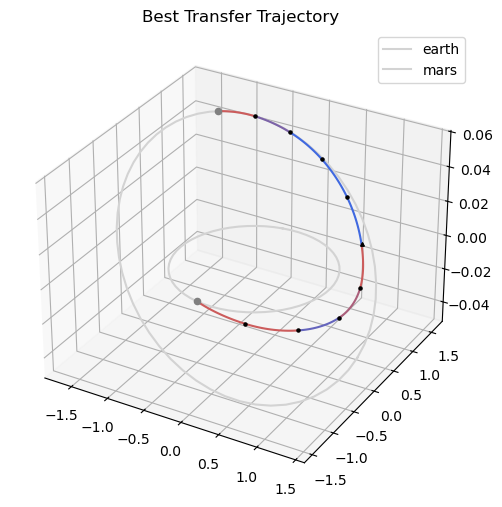

In [34]:
if len(xs) > 0:
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")
    t0 = udp.compute_t0(xs[best_idx])
    ax = pk.plot.add_planet_orbit(
        ax=ax, pla=earth, label="earth", units=L, color="lightgray"
    )
    ax = pk.plot.add_planet_orbit(
        ax=ax, pla=mars, label="mars", units=L, color="lightgray"
    )
    ax = udp.plot(xs[best_idx], ax=ax, N=20, c="k", s=5)
    ax = pk.plot.add_planet(ax=ax, when=t0, pla=earth, units=L, color="gray", s=20)
    ax = pk.plot.add_planet(
        ax=ax,
        when=t0 + xs[best_idx][10 + 4 * udp.nseg] * udp.TIME / pk.DAY2SEC,
        pla=mars,
        units=L,
        color="gray",
        s=20,
    )
    ax.set_title("Best Transfer Trajectory")
    ax.legend()

<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

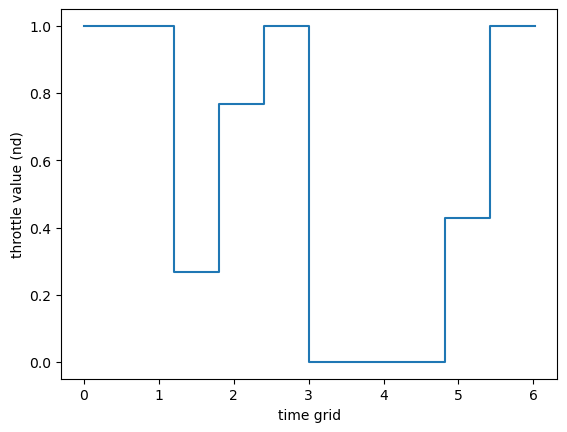

In [35]:
udp.plot_throttle(xs[best_idx])

# Two-body dynamics (Cartesian)

This section uses a TOPS two-body moving-boundary benchmark wrapped by {class}`pykep.trajopt.gym.tops_twobody_mb`, which solves the same benchmark with a free departure epoch.

Workflow:
1. load a named TOPS case (`P0`, `P1`, ...),
2. build the pygmo problem and set feasibility tolerance,
3. verify analytical gradients,
4. solve with IPOPT via multiple random restarts and inspect mass / time-of-flight / geometry.

In [36]:
# 1) Select a TOPS benchmark case and build the wrapped UDP
prob_name = "P0"
udp = pk.trajopt.gym.tops_twobody_mb(prob_name, nseg=10, time_encoding="uniform")
print(udp.extra_info)

Mildly-elliptic to mildly-elliptic transfer (e_s~0.201, e_f~0.210) in fixed tof -> T=0.22N, Isp=3000s


In [37]:
# 2) Wrap into a pygmo problem and set feasibility tolerance for reporting
prob = pg.problem(udp)
prob.c_tol = 1e-6  # This affects pagmo feasibility checks, not IPOPT's internal tol

In [38]:
# Compare analytical and finite-difference gradients at a random initial point
pop = pg.population(prob, 1)
grad_err = pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8) - udp.gradient(pop.champion_x)
grad_err.max(), grad_err.min()

(2.380128642700402e-07, -2.3552069690346844e-07)

In [39]:
# Solve via multiple random restarts; collect feasible results
seed = 42
pseudorandom = lambda i: (1103515245 * (i + seed) + 12345) % 2**31

masses = []
xs = []
for i in range(10):
    pop = pg.population(prob, 1, seed=pseudorandom(i))
    pop = algo.evolve(pop)
    if prob.feasibility_f(pop.champion_f):
        print(".", end="")
        masses.append(pop.champion_x[1])
        xs.append(pop.champion_x)
    else:
        print("x", end="")
print("\nBest mass is: ", np.max(masses))
print("Worst mass is: ", np.min(masses))
best_idx = np.argmax(masses)

..........
Best mass is:  0.927473080115
Worst mass is:  0.919774415651


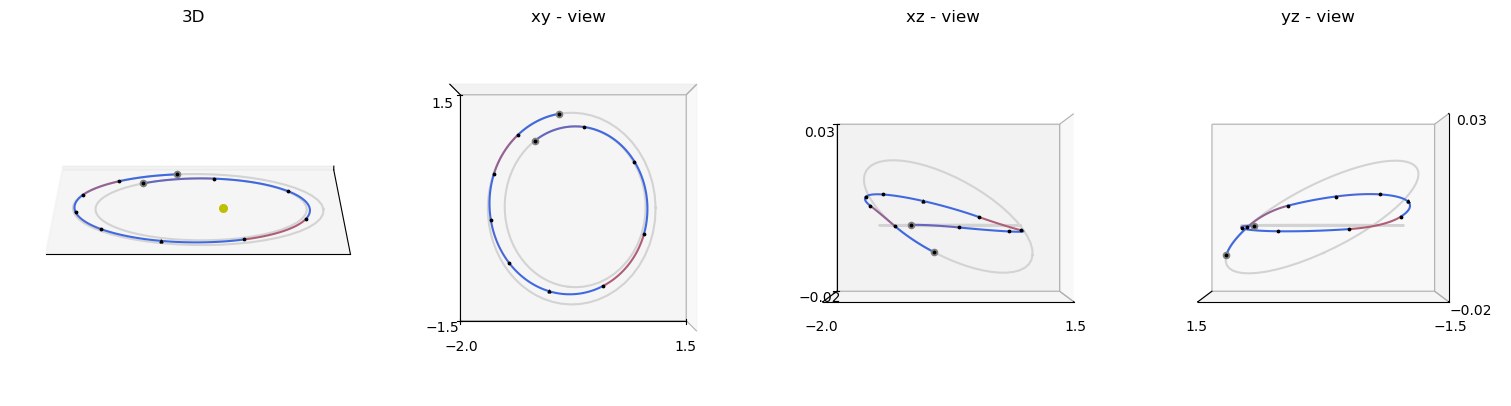

In [40]:
# Multi-view plotting helper for quick geometric inspection
axes = udp.plot(xs[best_idx], N=100, mark_segments=True, s=3, c="k")

<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

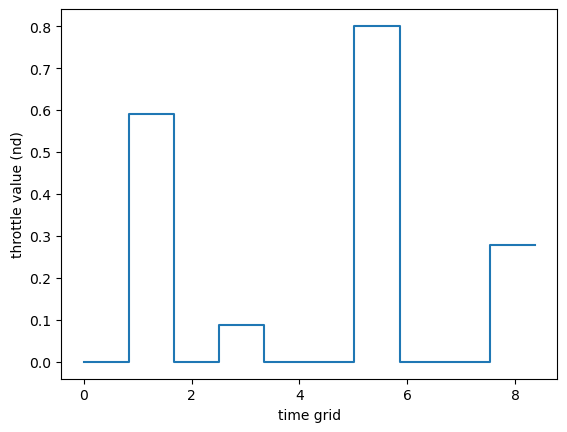

In [41]:
udp.plot_throttle(xs[best_idx])

# Two-body dynamics (Modified Equinoctial Elements)

We now solve the MEE moving-boundary variant through {class}`pykep.trajopt.gym.tops_mee_mb`, reusing the exact same numerical pipeline.

Only the internal dynamics/state representation changes; the user-facing optimization workflow remains identical.

For element definitions and conversions, see [Elements and conversions](../elements.rst).

In [42]:
# 1) Load a TOPS MEE moving-boundary benchmark and inspect its metadata
prob_name = "P0"
udp = pk.trajopt.gym.tops_mee_mb(prob_name, nseg=10, time_encoding="uniform")
print(udp.extra_info)

Dionysus problem (doi: 10.2514/1.G000379) - Fixed time


In [43]:
# 2) Wrap into a pygmo problem and set feasibility tolerance for reporting
prob = pg.problem(udp)
prob.c_tol = 1e-7  # This affects pagmo feasibility checks, not IPOPT's internal tol

In [44]:
# Compare analytical and finite-difference gradients at a random initial point
pop = pg.population(prob, 1)
grad_err = pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8) - udp.gradient(pop.champion_x)
grad_err.max(), grad_err.min()

(0.32638969140670759, -5.9453881122793515)

In [45]:
# Solve via multiple random restarts; collect feasible results
seed = 42
pseudorandom = lambda i: (1103515245 * (i + seed) + 12345) % 2**31

masses = []
xs = []
for i in range(10):
    pop = pg.population(prob, 1, seed=pseudorandom(i))
    pop = algo.evolve(pop)
    if prob.feasibility_f(pop.champion_f):
        print(".", end="")
        masses.append(pop.champion_x[1])
        xs.append(pop.champion_x)
    else:
        print("x", end="")
print("\nBest mass is: ", np.max(masses))
print("Worst mass is: ", np.min(masses))
best_idx = np.argmax(masses)

..........
Best mass is:  0.593691946213
Worst mass is:  0.574606213845


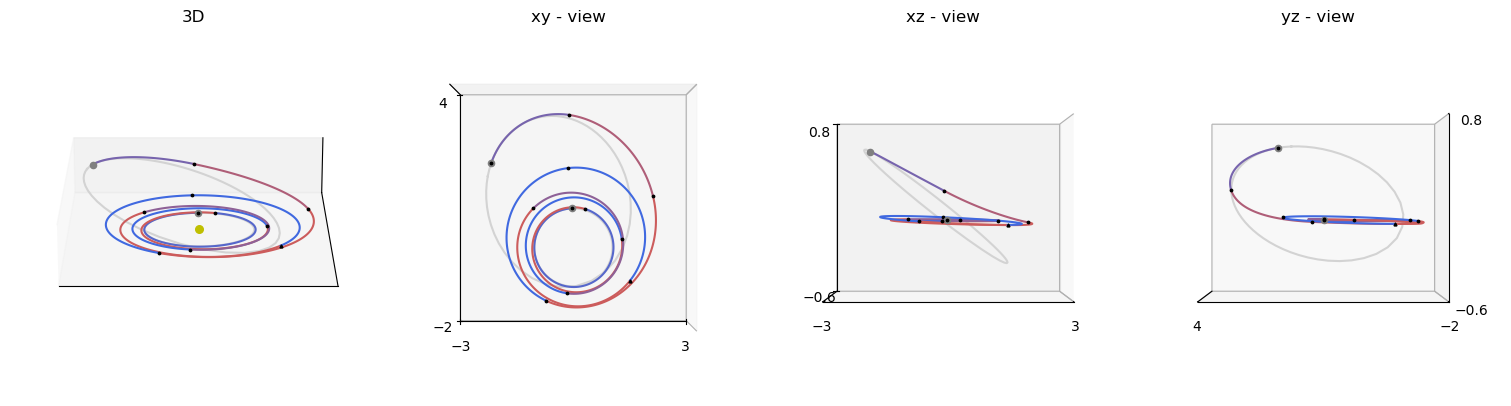

In [46]:
# Multi-view plotting helper for quick geometric inspection
axes = udp.plot(xs[best_idx], N=100, mark_segments=True, s=3, c="k")

<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

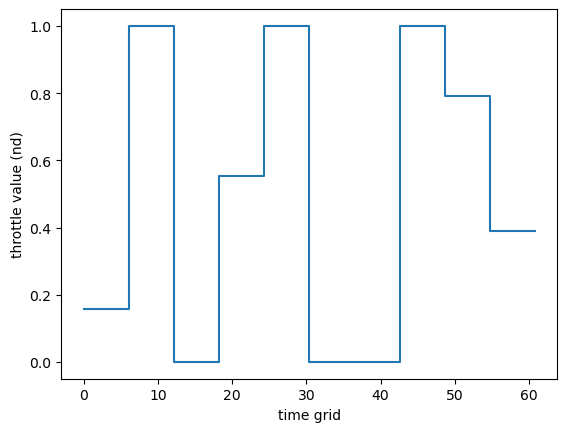

In [47]:
udp.plot_throttle(xs[best_idx])

# Circular Restricted Three-Body Problem (CR3BP)

This section uses {class}`pykep.trajopt.gym.tops_cr3bp_mb`.

The wrapper configures the CR3BP-specific dynamics and parameters internally, while keeping the same optimizer and validation structure used in previous sections.

For model background, see [CR3BP dynamics](../propagation.rst).

In [48]:
# 1) Load a TOPS CR3BP moving-boundary benchmark
prob_name = "P0"
udp = pk.trajopt.gym.tops_cr3bp_mb(prob_name, nseg=10, time_encoding="uniform", inequalities_for_tc=True)
print(udp.extra_info)

Halo 2 Halo in fixed tof


In [49]:
# 2) Wrap into a pygmo problem and set feasibility tolerance for reporting
prob = pg.problem(udp)
prob.c_tol = 1e-7  # This affects pagmo feasibility checks, not IPOPT's internal tol

In [50]:
# Compare analytical and finite-difference gradients at a random initial point
pop = pg.population(prob, 1)
grad_err = pg.estimate_gradient_h(udp.fitness, pop.champion_x, dx=1e-8) - udp.gradient(pop.champion_x)
grad_err.max(), grad_err.min()

(1.1840403081886386e-06, -1.0073217962952574e-06)

In [51]:
# Solve via multiple random restarts; collect feasible results
seed = 42
pseudorandom = lambda i: (1103515245 * (i + seed) + 12345) % 2**31

masses = []
xs = []
for i in range(10):
    pop = pg.population(prob, 1, seed=pseudorandom(i))
    pop = algo.evolve(pop)
    if prob.feasibility_f(pop.champion_f):
        print(".", end="")
        masses.append(pop.champion_x[1])
        xs.append(pop.champion_x)
    else:
        print("x", end="")
print("\nBest mass is: ", np.max(masses))
print("Worst mass is: ", np.min(masses))
best_idx = np.argmax(masses)

..........
Best mass is:  0.983423556625
Worst mass is:  0.943672823814


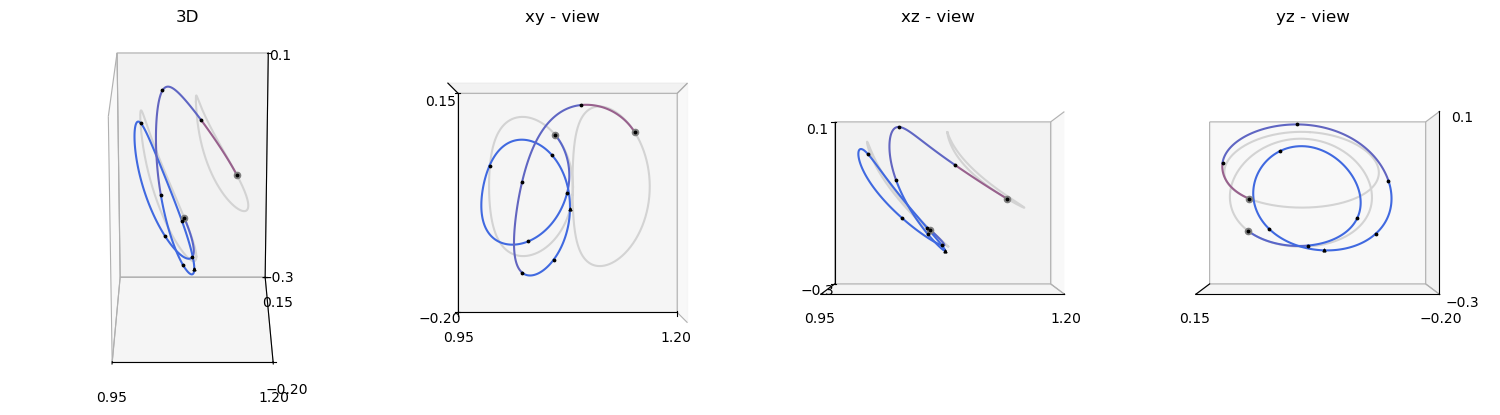

In [52]:
# Multi-view plotting helper for quick geometric inspection
axes = udp.plot(xs[best_idx], N=100, mark_segments=True, s=3, c="k")

<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

<Axes: xlabel='time grid', ylabel='throttle value (nd)'>

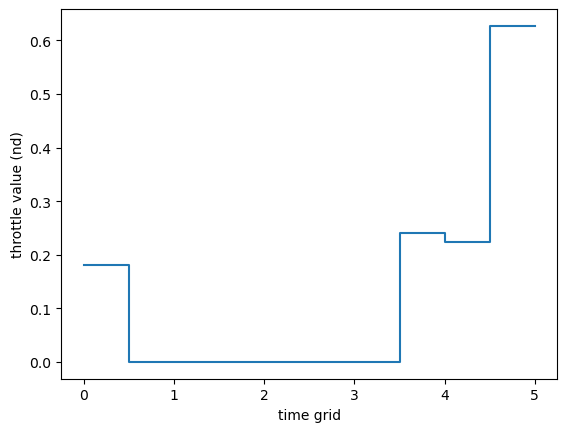

In [53]:
udp.plot_throttle(xs[best_idx])

# Solar-sail dynamics

Finally, we solve a TOPS solar-sail moving-boundary benchmark with {class}`pykep.trajopt.gym.tops_ss_mb`, internally based on {class}`pykep.trajopt.zoh_ss_point2point`.

As above, we keep the same verification-and-solve protocol (gradient check, IPOPT solve, trajectory inspection), so results are directly comparable across dynamics.

For additional sail-leg details, see the [Zero-Order Hold leg tutorial](./leg_zoh.ipynb) and [Trajectory optimization API](../trajopt.rst).

In [59]:
# 1) Load a TOPS solar-sail moving-boundary benchmark
prob_name = "P1"
udp = pk.trajopt.gym.tops_ss_mb(prob_name, nseg=10, time_encoding="softmax", inequalities_for_tc=True)
print(udp.extra_info)

Eccentric (e=0.5, a=2) to highly-eccentric (e=0.9, a=10) orbit at periapsis (rp=1, nd)


In [60]:
# 2) Wrap into a pygmo problem and set feasibility tolerance for reporting
prob = pg.problem(udp)
prob.c_tol = 1e-6  # This affects pagmo feasibility checks, not IPOPT's internal tol

In [75]:
# Compare analytical and finite-difference gradients at a random initial point
pop = pg.population(prob, 1)
grad_err = pg.estimate_gradient(udp.fitness, pop.champion_x, dx=1e-8) - udp.gradient(pop.champion_x)
grad_err.max(), grad_err.min()

(2.9871855176111239e-06, -1.4333349298567555e-05)

In [57]:
# Solve via multiple random restarts; collect feasible results
seed = 42
pseudorandom = lambda i: (1103515245 * (i + seed) + 12345) % 2**31

tofs = []
xs = []
for i in range(10):
    pop = pg.population(prob, 1, seed=pseudorandom(i))
    pop = algo.evolve(pop)
    if prob.feasibility_f(pop.champion_f):
        print(".", end="")
        tofs.append(pop.champion_x[9+2*udp.nseg])
        xs.append(pop.champion_x)
    else:
        print("x", end="")
print("\nBest tof is: ", np.min(tofs))
print("Worst tof is: ", np.max(tofs))
best_idx = np.argmin(tofs)

x....xxx.x
Best tof is:  180.0
Worst tof is:  180.0


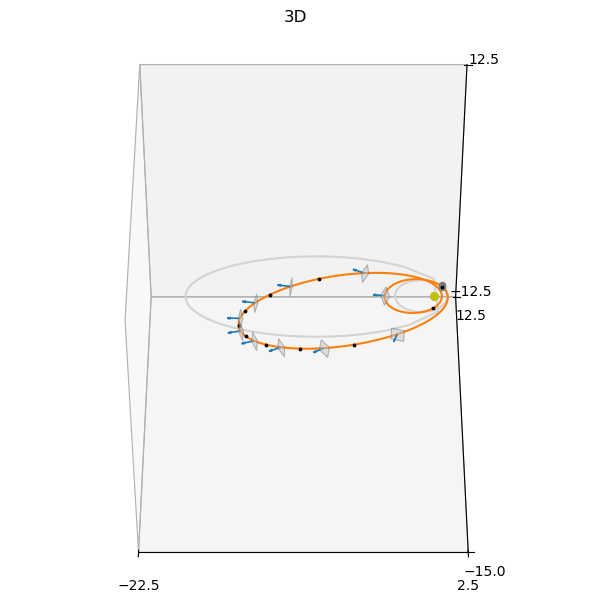

In [58]:
# Multi-view plotting helper for quick geometric inspection
axes = udp.plot(xs[best_idx], N=100, mark_segments=True, s=3, c="k", sail_size=0.5)